In [1]:
import os
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# load price history
data_folder = '../data/'
for file in os.listdir(data_folder):
    if 'price_history_full' in file:
        df = pd.read_csv(data_folder + file)

launch_ref = pd.read_csv('../data/official_launch_prices.csv')
df = df.merge(launch_ref, on='submodel_name')

df['official_premiere_date'] = pd.to_datetime(df['official_premiere_date'])
df['datetime'] = pd.to_datetime(df['datetime'])
df['days_since_launch'] = (df['datetime'] - df['official_premiere_date']).dt.days

df = df[df['days_since_launch'] > 0]
df['NEW'] = df['new_price'] * 100
df = df.drop('new_price', axis=1)

df['price_pct_of_launch'] = round(df['NEW'] / df['official_launch_price'] * 100, 1)
df['days_rounded'] = (df['days_since_launch'] / 7).round() * 7 #I had to do this to deal with duplicated lines on any line chart
df['tier'] = df.apply(lambda row: row['submodel_name'].replace(row['generation_name'], '').strip(), axis=1)
df['tier'] = df['tier'].replace('', 'Base')

#monthly sales rank df + tier
ms_df = pd.read_csv('../data/monthly_sold_full.csv')
ms_df = ms_df.merge(launch_ref, on='submodel_name', how='left')
ms_df['official_premiere_date'] = pd.to_datetime(ms_df['official_premiere_date'])
ms_df['datetime'] = pd.to_datetime(ms_df['datetime'])
del ms_df['premiere_date']
ms_df['days_since_launch'] = (ms_df['datetime'] - ms_df['official_premiere_date']).dt.days
ms_df['days_rounded'] = (ms_df['days_since_launch'] / 7).round() * 7
ms_df = ms_df[ms_df['days_since_launch'] >= 0]
ms_df['tier'] = ms_df.apply(lambda row: row['submodel_name'].replace(row['generation_name'], '').strip(), axis=1)
ms_df['tier'] = ms_df['tier'].replace('', 'Base')

# price decay dfs
base_apple_df = df[(df['tier'] == 'Base') & (df['brand'] == 'Apple') & (df['generation_name'] != 'iPhone 17')] #iPhone 17 excluded - it was launched recently and I downloaded this dataset quite some time ago
base_apple_decay_df = base_apple_df.groupby(['generation_name', 'product_grade', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()

base_samsung_df = df[(df['tier'] == 'Base') & (df['brand'] == 'Samsung')]
base_samsung_decay_df = base_samsung_df.groupby(['generation_name', 'product_grade', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()

base_google_df = df[(df['tier'] == 'Base') & (df['brand'] == 'Google')]
base_google_decay_df = base_google_df.groupby(['generation_name', 'product_grade', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()

base_combined_df = df[df['tier'] == 'Base']
all_brands_decay_df = base_combined_df.groupby(['brand', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()

grouped_generation_decay_df = df.groupby(['submodel_name', 'generation_name', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()
iphone13_decay_df = grouped_generation_decay_df[grouped_generation_decay_df['generation_name'] == 'iPhone 13']

#1-year price retention
yearly_change_df = df[(df['days_rounded'] > 330) & (df['days_rounded'] < 380)]
retention_1yr_df = yearly_change_df.groupby('generation_name').agg(
    price_retention=('price_pct_of_launch', 'mean'),
    brand=('brand', 'first')
).reset_index().sort_values('price_retention', ascending=False)

brand_retention = retention_1yr_df.groupby('brand')['price_retention'].mean()
apple_retention = brand_retention['Apple']
samsung_retention = brand_retention['Samsung']
google_retention = brand_retention['Google']

grade_means = df[(df['tier'] == 'Base') & (df['brand'] == 'Apple')].groupby('product_grade')['price_pct_of_launch'].mean()
renewed_premium_premium = grade_means['Renewed Premium'] - grade_means['Renewed']

# sales rank dataframes
apple_base_rank_df = ms_df[(ms_df['tier'] == 'Base') & (ms_df['brand'] == 'Apple') & (ms_df['monthly_sold'] >= 0)]
apple_base_rank_df = apple_base_rank_df.groupby(['generation_name', 'days_rounded'])['monthly_sold'].mean().reset_index()

iphone13_rank_df = ms_df[ms_df['generation_name'] == 'iPhone 13']
iphone13_rank_df = iphone13_rank_df.groupby(['submodel_name', 'days_rounded'])['monthly_sold'].mean().reset_index()

rank_dates_gen_df = (ms_df.set_index('datetime')
    .groupby(['generation_name', 'brand', 'tier'])
    .resample('W')['monthly_sold'].mean().reset_index())
rank_dates_gen_df['monthly_sold'] = rank_dates_gen_df.groupby('generation_name')['monthly_sold'].ffill()
apple_base_rank_dates_df = rank_dates_gen_df[
    (rank_dates_gen_df['tier'] == 'Base') &
    (rank_dates_gen_df['brand'] == 'Apple') &
    (rank_dates_gen_df['monthly_sold'] >= 0)
]

rank_dates_sub_df = (ms_df.set_index('datetime')
    .groupby(['submodel_name', 'brand', 'generation_name'])
    .resample('W')['monthly_sold'].mean().reset_index())
rank_dates_sub_df['monthly_sold'] = rank_dates_sub_df.groupby('generation_name')['monthly_sold'].ffill()
iphone13_rank_dates_df = rank_dates_sub_df[rank_dates_sub_df['generation_name'] == 'iPhone 13']


# Amazon Renewed Phone Price Analysis

This project looks at how the prices of refurbished smartphones decay after launch on Amazon US,
using historical price data from the Keepa API. The dataset covers Apple, Samsung and Google
across 63 submodels and roughly 878,000 weekly price records from 2019 to 2026.

Once a phone hits the secondary market, how fast does
it lose value, and does it depend on the brand, the model tier, or the time of year?

**Few notes on the data and methodology**

All prices for iPhones are for Renewed listings, not factory new. Apple phones on Amazon US
are exclusively sold by Renewed sellers, so for iPhones this dataset essentially captures the
full secondary market. Samsung and Google have both New and Renewed listings; where relevant,
the analysis separates them.

Launch prices were sourced manually from official press releases and represent the mean across
storage tiers - for example, iPhone 16 Pro ranged from $999 to $1,499 depending on storage (64 GB / 256 GB etc.),
so the reference price used here is $1,224. Locked variants were excluded since their
pricing dynamics differ slightly from unlocked units. Models launched very recently like the
iPhone 17 were also left out of decay charts due to not having enough price history to show
anythng meaningful yet.

---
# Key Metrics

In [2]:
fig = make_subplots(rows=2, cols=4, specs=[[{'type': 'indicator'}] * 4] * 2)

fig.add_trace(go.Indicator(mode='number', value=878267, title={'text': 'Price records'}), row=1, col=1)
fig.add_trace(go.Indicator(mode='number', value=3, title={'text': 'Brands'}), row=1, col=2)
fig.add_trace(go.Indicator(mode='number', value=df['generation_name'].nunique(), title={'text': 'Generations'}), row=1, col=3)
fig.add_trace(go.Indicator(mode='number', value=6, title={'text': 'Years of data'}), row=1, col=4)
fig.add_trace(go.Indicator(mode='number', value=round(apple_retention, 1), title={'text': 'Apple 1yr retention %'}), row=2, col=1)
fig.add_trace(go.Indicator(mode='number', value=round(samsung_retention, 1), title={'text': 'Samsung 1yr retention %'}), row=2, col=2)
fig.add_trace(go.Indicator(mode='number', value=round(google_retention, 1), title={'text': 'Google 1yr retention %'}), row=2, col=3)
fig.add_trace(go.Indicator(mode='number', value=round(renewed_premium_premium, 1), title={'text': 'Renewed Premium premium (pp)'}), row=2, col=4)

fig.update_layout(title_text='<b>Project KPI Summary</b>', height=600,
    paper_bgcolor='#f8f9fa', font=dict(size=13, color='#333333'))
for trace in fig.data:
    trace.title.font.size = 13
    trace.number.font.size = 36
fig.show()


---
# Price Decay analysis

Each chart below shows price as a percentage of the official launch price over time.
100% means the phone is still at its launch price on the Renewed market, 50% means it's
lost half its value. The x-axis shows days since launch so models can be compared at the
same point in their lifecycle regardless of when they were released.

**All brands - base models combined**

We're looking only at the base models, which means Pro, Pro Max, +, etc. submodels are not analyzed here.

In [3]:
pd_chart_1d = px.line(all_brands_decay_df, x='days_rounded', y='price_pct_of_launch',
    color='brand', title='Price decay — all base models by brand')
pd_chart_1d.update_yaxes(title_text='Price as % of launch price')
pd_chart_1d.update_xaxes(title_text='Days since launch')
pd_chart_1d.add_hline(y=50)
pd_chart_1d.show()


Apple phones are the last to hit the 50% mark, getting there at around 900 days after launch.
Samsung reaches it at roughly 500 days, Google at around 420 days. Apple also has the highest
price floor, stabilising at 26-28% of launch price after about 2000 days Samsung bottoms out
around 16-17% and Google around 20%, both also around the 2000 days mark.

**Apple base models by generation**

iPhones on Amazon are sold as Renewed or Renewed Premium only. Solid lines are standard Renewed,
dashed lines are Renewed Premium. iPhone 17 is excluded — too little data at this point.

In [4]:
pd_chart_1 = px.line(base_apple_decay_df, x='days_rounded', y='price_pct_of_launch',
    color='generation_name', line_dash='product_grade',
    title='Price decay — base iPhone models')
pd_chart_1.update_yaxes(title_text='Price as % of launch price')
pd_chart_1.update_xaxes(title_text='Days since launch')
pd_chart_1.add_hline(y=50)
pd_chart_1.show()


With no surprise, the Renewed Premium grade consistently sits above the standard Renewed curve for the same generation.
The gap stays fairly stable throughout the lifecycle, which suggests buyers
pay a persistent condition premium regardless of how old the phone gets. The exact difference
varies by generation but averages around 10.2 %.

**Samsung base models by generation**

In [5]:
pd_chart_1b = px.line(base_samsung_decay_df, x='days_rounded', y='price_pct_of_launch',
    color='generation_name',
    title='Price decay — base Samsung models')
pd_chart_1b.update_yaxes(title_text='Price as % of launch price')
pd_chart_1b.update_xaxes(title_text='Days since launch')
pd_chart_1b.add_hline(y=50)
pd_chart_1b.show()


**Google Pixel base models by generation**

In [6]:
pd_chart_1c = px.line(base_google_decay_df, x='days_rounded', y='price_pct_of_launch',
    color='generation_name',
    title='Price decay — base Google Pixel models')
pd_chart_1c.update_yaxes(title_text='Price as % of launch price')
pd_chart_1c.update_xaxes(title_text='Days since launch')
pd_chart_1c.add_hline(y=50)
pd_chart_1c.show()


**within a generation - iPhone 13 submodels**

All tiers normalised to 100% at their own first recorded price, so you can compare decay
shape directly without the different launch prices distorting the picture.

In [7]:
pd_chart_2 = px.line(iphone13_decay_df, x='days_rounded', y='price_pct_of_launch',
    color='submodel_name', title='Price decay — iPhone 13 submodels')
pd_chart_2.update_yaxes(title_text='Price as % of launch price')
pd_chart_2.update_xaxes(title_text='Days since launch')
pd_chart_2.add_hline(y=50)
pd_chart_2.show()


[TODO: observation about which submodel holds value best within iPhone 13]

---
# Brand comparison at one year post-launch

Instead of looking at the full decay curve, this takes a snapshot at around 365 days after
launch and lines up all generations side by side. It's a cleaner way to answer which phones
hold their value best in the first year.

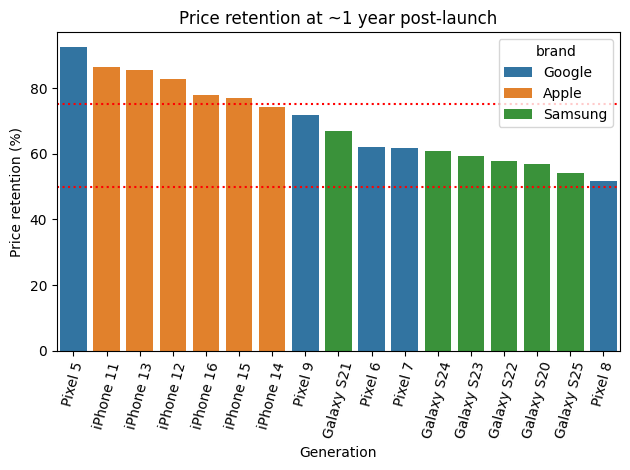

In [17]:
pd_chart_7 = sns.barplot(data=retention_1yr_df, x='generation_name', y='price_retention', hue='brand')
plt.axhline(75, color='red', linestyle='dotted')
plt.axhline(50, color='red', linestyle='dotted')
plt.title('Price retention at ~1 year post-launch')
plt.xlabel('Generation')
plt.ylabel('Price retention (%)')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


iPhones dominate the top of the chart. The Pixel 5 stands out as an anomaly among Google phones.
It launched at a low price ($699) and Google discontinued it earlier than expected, which constrained
supply and kept its secondary market value unusually stable. Other Pixel models, which launched at
higher prices and remained available for longer, didn't benefit from that same scarcity effect.

---
# Price distribution across the full lifecycle

The decay curves show averages. This boxplot shows the full spread of weekly prices across
the entire recorded lifecycle for each brand — median, quartiles, and outliers. It gives
a sense of how much variation there is within each brand, not just where the average lands.

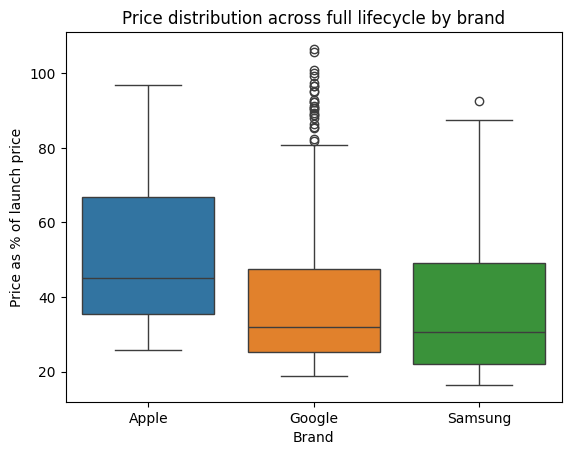

In [9]:
pd_chart_8 = sns.boxplot(data=all_brands_decay_df, x='brand', y='price_pct_of_launch', hue='brand')
plt.title('Price distribution across full lifecycle by brand')
plt.xlabel('Brand')
plt.ylabel('Price as % of launch price')
plt.show()


[TODO: observation about spread and median differences between brands]

---
# Sales rank analysis

Amazon's monthly_sold metric is a rank position, not a unit count - lower means the product
is selling more. Keepa only started tracking this consistently from late 2023, so there's
roughly 1.5 years of data to work with. The data here seems to be limited, but enough to see some lifecycle patterns.

I was wondering if it's worth it to include it, but this seems like a very important metric, so I couldn't just leave it out in this case.

**Sales rank over the product lifecycle — base iPhones**

In [18]:
ms_chart_3 = px.line(apple_base_rank_df, x='days_rounded', y='monthly_sold',
    color='generation_name',
    title='Sales rank over time — base iPhones by generation (the higher sales rank = the better)')
ms_chart_3.update_yaxes(autorange='reversed', title_text='Monthly sales rank')
ms_chart_3.update_xaxes(title_text='Days since launch')
ms_chart_3.show()


[TODO: observation about lifecycle deterioration and any exceptions]

**Sales rank within a generation on the example of all submodels of iPhone 13**

In [11]:
ms_chart_4 = px.line(iphone13_rank_df, x='days_rounded', y='monthly_sold',
    color='submodel_name',
    title='Sales rank over time — iPhone 13 submodels (lower = more sold)')
ms_chart_4.update_yaxes(autorange='reversed', title_text='Monthly sales rank')
ms_chart_4.update_xaxes(title_text='Days since launch')
ms_chart_4.show()


The Pro Max appears to be the most popular submodel in the iPhone 13 lineup. A bit counterintuitive
at first, as you'd expect the cheaper base model to sell more, but at this stage of the lifecycle
the Pro Max is deeply discounted from its $1,099 launch price and still offers the best hardware
of the generation. Buyers looking for a budget flagship will often go for the top tier once the
price is right.

**Sales rank on real calendar dates - base iPhones**

Using actual dates rather than days since launch makes it possible to spot seasonal patterns.
Gray dotted lines mark the September iPhone launch window, orange is Black Friday, red is Christmas.
Data starts from late 2023, so there are only two seasonal cycles visible.

In [19]:
ms_chart_5 = px.line(apple_base_rank_dates_df, x='datetime', y='monthly_sold',
    color='generation_name',
    title='Sales rank over time — base iPhones (real dates)')
ms_chart_5.update_yaxes(autorange='reversed', title_text='Monthly sales rank')
ms_chart_5.update_xaxes(title_text='Date')
ms_chart_5.add_scatter(x=[None], y=[None], mode='lines',
    line=dict(color='gray', dash='dot', width=1), name='new iPhone Launch (Sep)')
ms_chart_5.add_scatter(x=[None], y=[None], mode='lines',
    line=dict(color='orange', dash='dot', width=1), name='Black Friday (Nov)')
ms_chart_5.add_scatter(x=[None], y=[None], mode='lines',
    line=dict(color='red', dash='dot', width=1), name='Christmas (Dec)')
for year in range(2023, 2026):
    ms_chart_5.add_vline(x=int(pd.Timestamp(f'{year}-09-15').timestamp() * 1000),
        line_dash='dot', line_color='gray', line_width=1)
    ms_chart_5.add_vline(x=int(pd.Timestamp(f'{year}-11-25').timestamp() * 1000),
        line_dash='dot', line_color='orange', line_width=1)
    ms_chart_5.add_vline(x=int(pd.Timestamp(f'{year}-12-20').timestamp() * 1000),
        line_dash='dot', line_color='red', line_width=1)
ms_chart_5.show()


[TODO: seasonal observation — any visible uptick in sales around BF/Christmas?]

**iPhone 13 submodels on real calendar dates**

In [13]:
ms_chart_6 = px.line(iphone13_rank_dates_df, x='datetime', y='monthly_sold',
    color='submodel_name',
    title='Sales rank over time — iPhone 13 submodels (real dates)')
ms_chart_6.update_yaxes(autorange='reversed', title_text='Monthly sales rank')
ms_chart_6.update_xaxes(title_text='Date')
ms_chart_6.add_scatter(x=[None], y=[None], mode='lines',
    line=dict(color='gray', dash='dot', width=1), name='iPhone Launch (Sep)')
ms_chart_6.add_scatter(x=[None], y=[None], mode='lines',
    line=dict(color='orange', dash='dot', width=1), name='Black Friday (Nov)')
ms_chart_6.add_scatter(x=[None], y=[None], mode='lines',
    line=dict(color='red', dash='dot', width=1), name='Christmas (Dec)')
for year in range(2023, 2026):
    ms_chart_6.add_vline(x=int(pd.Timestamp(f'{year}-09-15').timestamp() * 1000),
        line_dash='dot', line_color='gray', line_width=1)
    ms_chart_6.add_vline(x=int(pd.Timestamp(f'{year}-11-25').timestamp() * 1000),
        line_dash='dot', line_color='orange', line_width=1)
    ms_chart_6.add_vline(x=int(pd.Timestamp(f'{year}-12-20').timestamp() * 1000),
        line_dash='dot', line_color='red', line_width=1)
ms_chart_6.show()


---
# Key Findings

- **Apple retains value best.** At the one-year mark, iPhones hold significantly more of their
  launch price than Samsung or Google. The 50% barrier comes around 900 days for Apple vs
  roughly 500 days for Samsung and 420 for Google.

- **Renewed Premium holds its value better than standard Renewed.** For iPhones the gap
  averages around [TODO: renewed_premium_premium] percentage points and stays fairly stable
  throughout the lifecycle — it's not just a launch-window premium.

- **The Pixel 5 is an anomaly.** It outperforms every other model at the one-year mark.
  Low launch price plus early discontinuation created supply constraints that kept its
  secondary market value elevated longer than expected.

- **Older flagships attract buyers looking for the best hardware at a discount.** The iPhone 13
  Pro Max shows stronger sales rank than cheaper submodels of the same generation, suggesting
  people actively seek out the top tier once the price drops to a reasonable level.

- **Seasonal sales data is limited.** The monthly_sold metric only covers from late 2023,
  making it hard to draw firm conclusions about Black Friday or Christmas effects. There are
  hints of demand improvement around the holiday window but more history is needed to say
  anything with confidence.